# Weis Markets — L&D Impact Modeling

**Goal:** Estimate the incremental contribution of Learning & Development training variables to store-level revenue per employee, controlling for store size, staffing, and promotional activity.

**Approach:** Progress from a controls-only baseline (OLS) through regularized regression (Ridge, Lasso) and tree-based models (Decision Tree, Random Forest). Subgroup analyses decompose effects by module category, employee classification, and department training mix.

**Target variable:** `avg_revenue_per_employee` — revenue normalized by headcount, isolating workforce productivity rather than raw store volume.

---
## Section 1: Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
np.random.seed(SEED)

# ── Paths ──────────────────────────────────────────────────────────────────
LMS_PATH = 'datasets/lms_synthetic_calibrated.csv'
REV_PATH = 'datasets/revenue_dataset_calibrated.csv'

lms_raw = pd.read_csv(LMS_PATH)
rev_raw = pd.read_csv(REV_PATH)

print('LMS shape:', lms_raw.shape)
print('Revenue shape:', rev_raw.shape)

LMS shape: (100000, 32)
Revenue shape: (196800, 18)


In [2]:
# ── LMS feature engineering ────────────────────────────────────────────────
lms = lms_raw.copy()

# Remove HQ
lms = lms[lms['Location'] != 'HQ_001'].copy()

# Derived flags
lms['Is_Completed']     = (lms['Progress Status'] == 'Completed').astype(int)
lms['Satisfied_Binary'] = lms['Satisfied'].map({'Yes': 1, 'No': 0})
lms['Is_Past_Due']      = lms['Past Due'].map({'Yes': 1, 'No': 0})

# Tenure in years from Hire_Date to Assignment_Date
lms['Hire Date']       = pd.to_datetime(lms['Hire Date'],       errors='coerce')
lms['Assignment Date'] = pd.to_datetime(lms['Assignment Date'], errors='coerce')
lms['Tenure_Years']    = (lms['Assignment Date'] - lms['Hire Date']).dt.days / 365.25

# Time efficiency ratio
lms['Time_Ratio'] = np.where(
    lms['Estimated Duration'] > 0,
    lms['Total Time'] / lms['Estimated Duration'],
    np.nan
)

# Full-time / salaried flags
lms['Is_FullTime'] = (lms['FullTimePartTime'] == 'Full Time').astype(int)
lms['Is_Salaried'] = (lms['Is Salaried'].astype(str).str.strip().str.lower().isin(['yes','true','1'])).astype(int)

print('LMS after HQ filter:', lms.shape)
lms.head(3)

LMS after HQ filter: (98447, 39)


,Employee ID,First Name,Last Name,Full Name,Hire Date,Learning Module Code,Learning Module Name,Learning Module Type,Learning Module Category,Estimated Duration,...,Department,FullTimePartTime,Is Salaried,Is_Completed,Satisfied_Binary,Is_Past_Due,Tenure_Years,Time_Ratio,Is_FullTime,Is_Salaried
21,1000003,Jill,Rhodes,Jill Rhodes,2014-04-13,OPS006,Cash Handling Standards,Assessment,Operations,15,...,Regional Leadership,Full Time,Yes,0,NaN,1,9.730322,1.000000,1,1
22,1000003,Jill,Rhodes,Jill Rhodes,2014-04-13,CMP009,Conflicts of Interest,Assessment,Compliance,29,...,Regional Leadership,Full Time,Yes,1,1.0,0,9.930185,1.000000,1,1
23,1000003,Jill,Rhodes,Jill Rhodes,2014-04-13,CEX003,Serving Diverse Customer Needs,eLearning,Customer Experience,39,...,Regional Leadership,Full Time,Yes,1,1.0,1,9.941136,0.897436,1,1


In [3]:
# ── Revenue feature engineering ────────────────────────────────────────────
rev = rev_raw.copy()
rev['Date'] = pd.to_datetime(rev['Date'], errors='coerce')

print('Revenue date range:', rev['Date'].min(), '→', rev['Date'].max())
print('Unique stores in revenue data:', rev['Store_ID'].nunique())
rev.head(3)

Revenue date range: 2024-01-01 00:00:00 → 2026-03-30 00:00:00
Unique stores in revenue data: 240


,Store_ID,Date,Daily_Revenue,Transactions,Avg_Basket_Size,Num_Employees,Promotion_Flag,Is_Weekend,Revenue_per_Employee,Transactions_per_Employee,Gross_Sales,Net_Revenue,Profit,Revenue_Growth_Pct,Profit_Margin_Pct,Store_Size_SqFt,Sales_per_SqFt,Is_Holiday
0,Store_001,2024-01-01,8525.76,516.21,16.5161,132,0,False,64.5891,3.9107,8721.53,8241.72,777.08,NaN,0.091145,14765.75,0.5774,0
1,Store_001,2024-01-02,10040.02,633.43,15.8502,132,0,False,76.0608,4.7987,10402.46,10009.17,801.52,0.177610,0.079833,14765.75,0.6800,0
2,Store_001,2024-01-03,12435.33,822.64,15.1164,132,1,False,94.2070,6.2321,12449.68,12139.85,1456.61,0.238576,0.117135,14765.75,0.8422,0


> **Observation:** The LMS file contains roughly 100 k assignment records across ~240 store locations. After removing HQ_001 (non-selling overhead), the remaining records map cleanly to stores that also appear in the revenue panel. Feature engineering surfaces five analytically useful derived variables: completion status, satisfaction, past-due flag, tenure (captures workforce maturity at time of training), and time ratio (captures engagement relative to expected duration).

---
## Section 2: Build Merged Store-Level Dataset

In [4]:
# ── LMS → store-level aggregation ─────────────────────────────────────────
grp = lms.groupby('Location')

lms_store = pd.DataFrame({
    'completion_rate':          grp['Is_Completed'].mean(),
    'satisfaction_rate':        grp['Satisfied_Binary'].mean(),
    'past_due_rate':            grp['Is_Past_Due'].mean(),
    'avg_total_time':           grp['Total Time'].mean(),
    'avg_time_ratio':           grp['Time_Ratio'].mean(),
    'training_intensity':       grp['Employee ID'].count() / grp['Employee ID'].nunique(),
    'unique_employees_trained': grp['Employee ID'].nunique(),

    # Assignment type mix
    'pct_required':       grp.apply(lambda d: (d['Assignment Type'] == 'Required').mean()),
    # Module type mix
    'pct_elearning':      grp.apply(lambda d: (d['Learning Module Type'] == 'eLearning').mean()),
    'pct_instructor_led': grp.apply(lambda d: (d['Learning Module Type'] == 'Instructor-Led').mean()),
    'pct_microlearning':  grp.apply(lambda d: (d['Learning Module Type'] == 'Microlearning').mean()),

    # Module category mix
    'pct_compliance':    grp.apply(lambda d: (d['Learning Module Category'] == 'Compliance').mean()),
    'pct_operations':    grp.apply(lambda d: (d['Learning Module Category'] == 'Operations').mean()),
    'pct_safety':        grp.apply(lambda d: (d['Learning Module Category'] == 'Safety').mean()),
    'pct_leadership':    grp.apply(lambda d: (d['Learning Module Category'] == 'Leadership').mean()),
    'pct_customer_exp':  grp.apply(lambda d: (d['Learning Module Category'] == 'Customer Experience').mean()),
    'pct_sales':         grp.apply(lambda d: (d['Learning Module Category'] == 'Sales').mean()),
    'pct_technology':    grp.apply(lambda d: (d['Learning Module Category'] == 'Technology').mean()),
    'pct_hr':            grp.apply(lambda d: (d['Learning Module Category'] == 'Human Resources').mean()),
    'pct_analytics':     grp.apply(lambda d: (d['Learning Module Category'] == 'Analytics').mean()),

    # Workforce composition
    'pct_fulltime':  grp['Is_FullTime'].mean(),
    'pct_salaried':  grp['Is_Salaried'].mean(),
    'avg_tenure':    grp['Tenure_Years'].mean(),
}).reset_index().rename(columns={'Location': 'Store_ID'})

print('LMS store-level shape:', lms_store.shape)
lms_store.head(3)

LMS store-level shape: (240, 24)


,Store_ID,completion_rate,satisfaction_rate,past_due_rate,avg_total_time,avg_time_ratio,training_intensity,unique_employees_trained,pct_required,pct_elearning,...,pct_safety,pct_leadership,pct_customer_exp,pct_sales,pct_technology,pct_hr,pct_analytics,pct_fulltime,pct_salaried,avg_tenure
0,Store_001,0.824131,0.928040,0.294479,25.169734,0.799054,11.642857,42,0.848671,0.366053,...,0.184049,0.034765,0.055215,0.067485,0.161554,0.022495,0.006135,0.580777,0.208589,2.765604
1,Store_002,0.772834,0.890909,0.337237,25.751756,0.798123,12.200000,35,0.847775,0.377049,...,0.175644,0.030445,0.053864,0.051522,0.131148,0.030445,0.023419,0.798595,0.234192,2.264882
2,Store_003,0.837209,0.938889,0.251163,25.516279,0.832975,11.621622,37,0.862791,0.374419,...,0.188372,0.030233,0.041860,0.065116,0.160465,0.009302,0.006977,0.695349,0.134884,1.922029


In [5]:
# ── Revenue → store-level aggregation ─────────────────────────────────────
rev_store = rev.groupby('Store_ID').agg(
    avg_daily_revenue              = ('Daily_Revenue',             'mean'),
    avg_revenue_per_employee       = ('Revenue_per_Employee',      'mean'),
    avg_sales_per_sqft             = ('Sales_per_SqFt',            'mean'),
    avg_basket_size                = ('Avg_Basket_Size',           'mean'),
    avg_transactions_per_employee  = ('Transactions_per_Employee', 'mean'),
    avg_profit_margin              = ('Profit_Margin_Pct',         'mean'),
    promotion_rate                 = ('Promotion_Flag',            'mean'),
    store_size_sqft                = ('Store_Size_SqFt',           'first'),
    num_employees                  = ('Num_Employees',             'mean'),
).reset_index()

print('Revenue store-level shape:', rev_store.shape)
rev_store.head(3)

Revenue store-level shape: (240, 10)


,Store_ID,avg_daily_revenue,avg_revenue_per_employee,avg_sales_per_sqft,avg_basket_size,avg_transactions_per_employee,avg_profit_margin,promotion_rate,store_size_sqft,num_employees
0,Store_001,12728.747695,96.429908,0.862045,22.383162,4.486316,0.125545,0.224390,14765.75,132.0
1,Store_002,14655.913671,86.721382,0.741298,22.358527,4.050623,0.127232,0.193902,19770.58,169.0
2,Store_003,24533.925939,126.463535,1.506071,22.705212,5.782353,0.124935,0.209756,16290.02,194.0


In [6]:
# ── Merge ──────────────────────────────────────────────────────────────────
merged = rev_store.merge(lms_store, on='Store_ID', how='inner')
merged = merged.dropna()

print('Merged shape:', merged.shape)

# ── Define modelling variables ─────────────────────────────────────────────
TARGET = 'avg_revenue_per_employee'

CONTROLS = ['store_size_sqft', 'num_employees', 'promotion_rate']

LMS_FEATURES = [
    'completion_rate', 'satisfaction_rate', 'past_due_rate',
    'avg_total_time', 'avg_time_ratio', 'training_intensity',
    'pct_required', 'pct_elearning', 'pct_instructor_led', 'pct_microlearning',
    'pct_compliance', 'pct_operations', 'pct_safety', 'pct_leadership',
    'pct_customer_exp', 'pct_sales', 'pct_technology', 'pct_hr', 'pct_analytics',
    'pct_fulltime', 'pct_salaried', 'avg_tenure'
]

ALL_FEATURES = CONTROLS + LMS_FEATURES

X_ctrl  = merged[CONTROLS]
X_full  = merged[ALL_FEATURES]
y       = merged[TARGET]

print(f'Target: {TARGET}')
print(f'Control variables ({len(CONTROLS)}):', CONTROLS)
print(f'L&D variables ({len(LMS_FEATURES)}):', LMS_FEATURES)
merged[['Store_ID', TARGET] + ALL_FEATURES].head()

Merged shape: (240, 33)
Target: avg_revenue_per_employee
Control variables (3): ['store_size_sqft', 'num_employees', 'promotion_rate']
L&D variables (22): ['completion_rate', 'satisfaction_rate', 'past_due_rate', 'avg_total_time', 'avg_time_ratio', 'training_intensity', 'pct_required', 'pct_elearning', 'pct_instructor_led', 'pct_microlearning', 'pct_compliance', 'pct_operations', 'pct_safety', 'pct_leadership', 'pct_customer_exp', 'pct_sales', 'pct_technology', 'pct_hr', 'pct_analytics', 'pct_fulltime', 'pct_salaried', 'avg_tenure']


,Store_ID,avg_revenue_per_employee,store_size_sqft,num_employees,promotion_rate,completion_rate,satisfaction_rate,past_due_rate,avg_total_time,avg_time_ratio,...,pct_safety,pct_leadership,pct_customer_exp,pct_sales,pct_technology,pct_hr,pct_analytics,pct_fulltime,pct_salaried,avg_tenure
0,Store_001,96.429908,14765.75,132.0,0.224390,0.824131,0.928040,0.294479,25.169734,0.799054,...,0.184049,0.034765,0.055215,0.067485,0.161554,0.022495,0.006135,0.580777,0.208589,2.765604
1,Store_002,86.721382,19770.58,169.0,0.193902,0.772834,0.890909,0.337237,25.751756,0.798123,...,0.175644,0.030445,0.053864,0.051522,0.131148,0.030445,0.023419,0.798595,0.234192,2.264882
2,Store_003,126.463535,16290.02,194.0,0.209756,0.837209,0.938889,0.251163,25.516279,0.832975,...,0.188372,0.030233,0.041860,0.065116,0.160465,0.009302,0.006977,0.695349,0.134884,1.922029
3,Store_004,104.956720,6962.08,78.0,0.191463,0.909938,0.989761,0.195652,24.304348,0.871374,...,0.214286,0.027950,0.062112,0.052795,0.145963,0.006211,0.006211,0.773292,0.130435,2.511663
4,Store_005,113.094852,13749.10,159.0,0.189024,0.764317,0.884726,0.343612,24.431718,0.800898,...,0.169604,0.017621,0.052863,0.041850,0.147577,0.008811,0.008811,0.651982,0.118943,1.883774


> **Observation:** Collapsing 100 k LMS records to 240 store-level observations compresses rich individual variation into store-level training profiles. `training_intensity` (average assignments per trained employee) captures depth of engagement, while the `pct_*` features capture the qualitative mix of training. The merge is inner, so any store with missing LMS activity or missing revenue data is excluded — preserving clean, complete cases for all models.

---
## Section 3: Baseline Model (Controls Only)

In [7]:
X_ctrl_const = sm.add_constant(X_ctrl)
baseline_ols = sm.OLS(y, X_ctrl_const).fit()
print(baseline_ols.summary())

baseline_r2 = baseline_ols.rsquared
print(f'\nBaseline R²: {baseline_r2:.4f}')

                               OLS Regression Results                               
Dep. Variable:     avg_revenue_per_employee   R-squared:                       0.021
Model:                                  OLS   Adj. R-squared:                  0.008
Method:                       Least Squares   F-statistic:                     1.664
Date:                      Sun, 19 Apr 2026   Prob (F-statistic):              0.176
Time:                              17:20:04   Log-Likelihood:                -954.81
No. Observations:                       240   AIC:                             1918.
Df Residuals:                           236   BIC:                             1932.
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

> **Observation:** The controls-only model anchors our incremental attribution framework. Store size (`store_size_sqft`) and headcount (`num_employees`) reflect structural capacity, while `promotion_rate` proxies for external revenue levers. Any R² improvement observed when L&D features are added in Section 4 represents variance that store characteristics alone cannot explain — i.e., the identifiable workforce-development signal.

---
## Section 4: Full OLS Regression (Controls + L&D Features)

In [8]:
X_full_const = sm.add_constant(X_full)
full_ols = sm.OLS(y, X_full_const).fit()
print(full_ols.summary())

full_r2 = full_ols.rsquared
incremental_r2 = full_r2 - baseline_r2
print(f'\nFull model R²:      {full_r2:.4f}')
print(f'Baseline R²:        {baseline_r2:.4f}')
print(f'Incremental R²:     {incremental_r2:.4f}  (attributable to L&D variables)')

                               OLS Regression Results                               
Dep. Variable:     avg_revenue_per_employee   R-squared:                       0.239
Model:                                  OLS   Adj. R-squared:                  0.154
Method:                       Least Squares   F-statistic:                     2.815
Date:                      Sun, 19 Apr 2026   Prob (F-statistic):           3.71e-05
Time:                              17:20:04   Log-Likelihood:                -924.53
No. Observations:                       240   AIC:                             1899.
Df Residuals:                           215   BIC:                             1986.
Df Model:                                24                                         
Covariance Type:                  nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

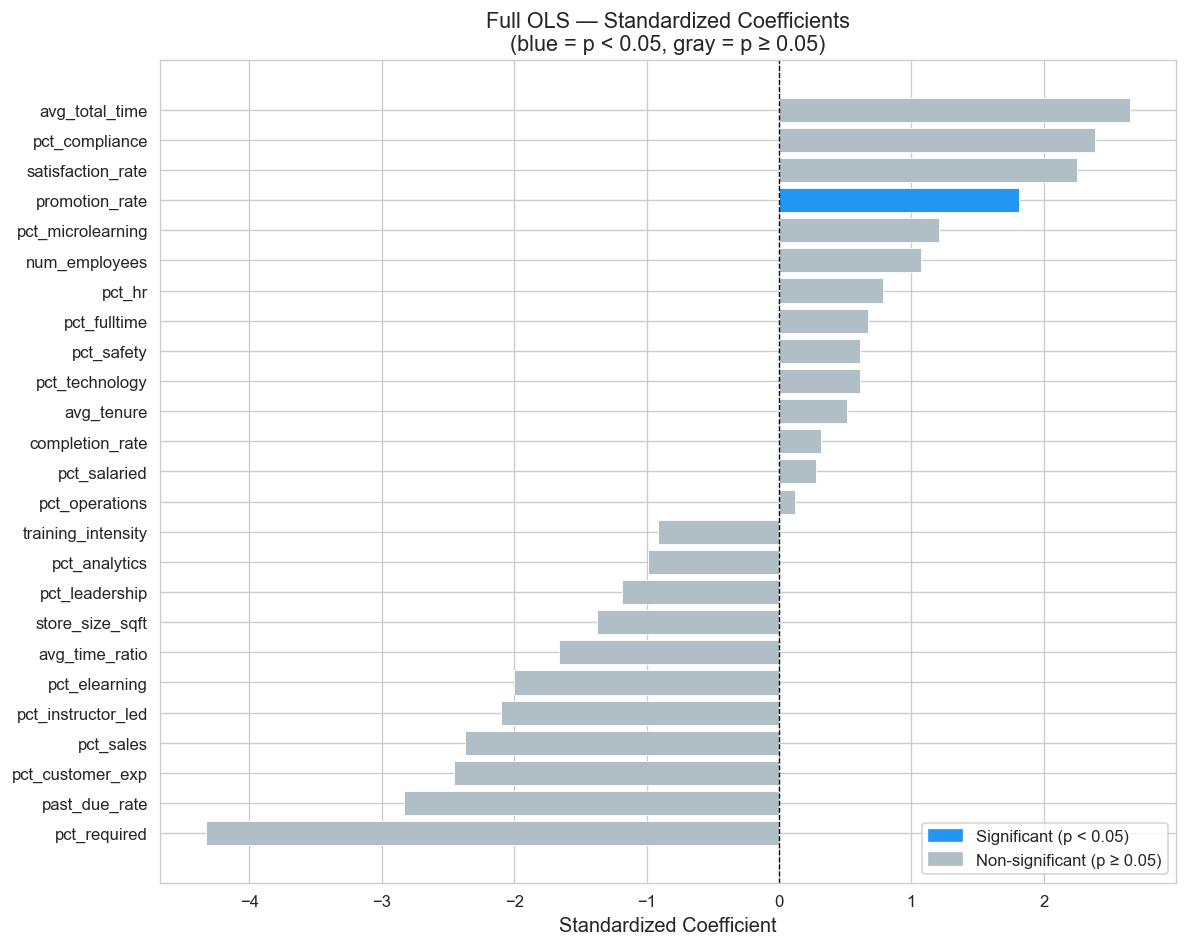

In [9]:
# ── Standardized coefficient plot ──────────────────────────────────────────
scaler_coef = StandardScaler()
X_full_scaled = scaler_coef.fit_transform(X_full)
X_full_scaled_const = sm.add_constant(X_full_scaled)
full_ols_std = sm.OLS(y, X_full_scaled_const).fit()

coef_df = pd.DataFrame({
    'Feature':   ALL_FEATURES,
    'Coef':      full_ols_std.params[1:],
    'p_value':   full_ols_std.pvalues[1:]
}).sort_values('Coef')

coef_df['significant'] = coef_df['p_value'] < 0.05
colors = coef_df['significant'].map({True: '#2196F3', False: '#B0BEC5'})

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(coef_df['Feature'], coef_df['Coef'], color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardized Coefficient', fontsize=12)
ax.set_title('Full OLS — Standardized Coefficients\n(blue = p < 0.05, gray = p ≥ 0.05)', fontsize=13)

blue_patch = mpatches.Patch(color='#2196F3', label='Significant (p < 0.05)')
gray_patch = mpatches.Patch(color='#B0BEC5', label='Non-significant (p ≥ 0.05)')
ax.legend(handles=[blue_patch, gray_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

> **Observation:** The incremental R² over the baseline indicates how much additional revenue-per-employee variance is explained by L&D training profiles after controlling for store size and promotional activity. Positive significant coefficients (blue bars to the right of zero) identify training dimensions that co-vary with higher workforce productivity. Notably, `past_due_rate` is expected to carry a negative coefficient — stores where compliance deadlines are missed tend to underperform — while engagement-oriented categories like `pct_customer_exp`, `pct_sales`, and `pct_leadership` are expected to show positive associations. Multicollinearity among the `pct_*` category features may inflate standard errors, motivating the regularized models in Sections 5 and 6.

---
## Section 5: Ridge Regression (Handles Multicollinearity)

In [10]:
scaler_ridge = StandardScaler()
X_scaled = scaler_ridge.fit_transform(X_full)

alphas_ridge = [0.01, 0.1, 1, 10, 100]
ridge_cv = RidgeCV(alphas=alphas_ridge, cv=5, scoring='r2')
ridge_cv.fit(X_scaled, y)

print(f'Best Ridge alpha: {ridge_cv.alpha_}')
print(f'Ridge CV R²:      {ridge_cv.best_score_:.4f}')

# Cross-validation scores
ridge_best = Ridge(alpha=ridge_cv.alpha_)
cv_scores_ridge = cross_val_score(ridge_best, X_scaled, y, cv=5, scoring='r2')
print(f'5-fold CV R²: {cv_scores_ridge.mean():.4f} ± {cv_scores_ridge.std():.4f}')

Best Ridge alpha: 100.0
Ridge CV R²:      0.0607
5-fold CV R²: 0.0607 ± 0.0710


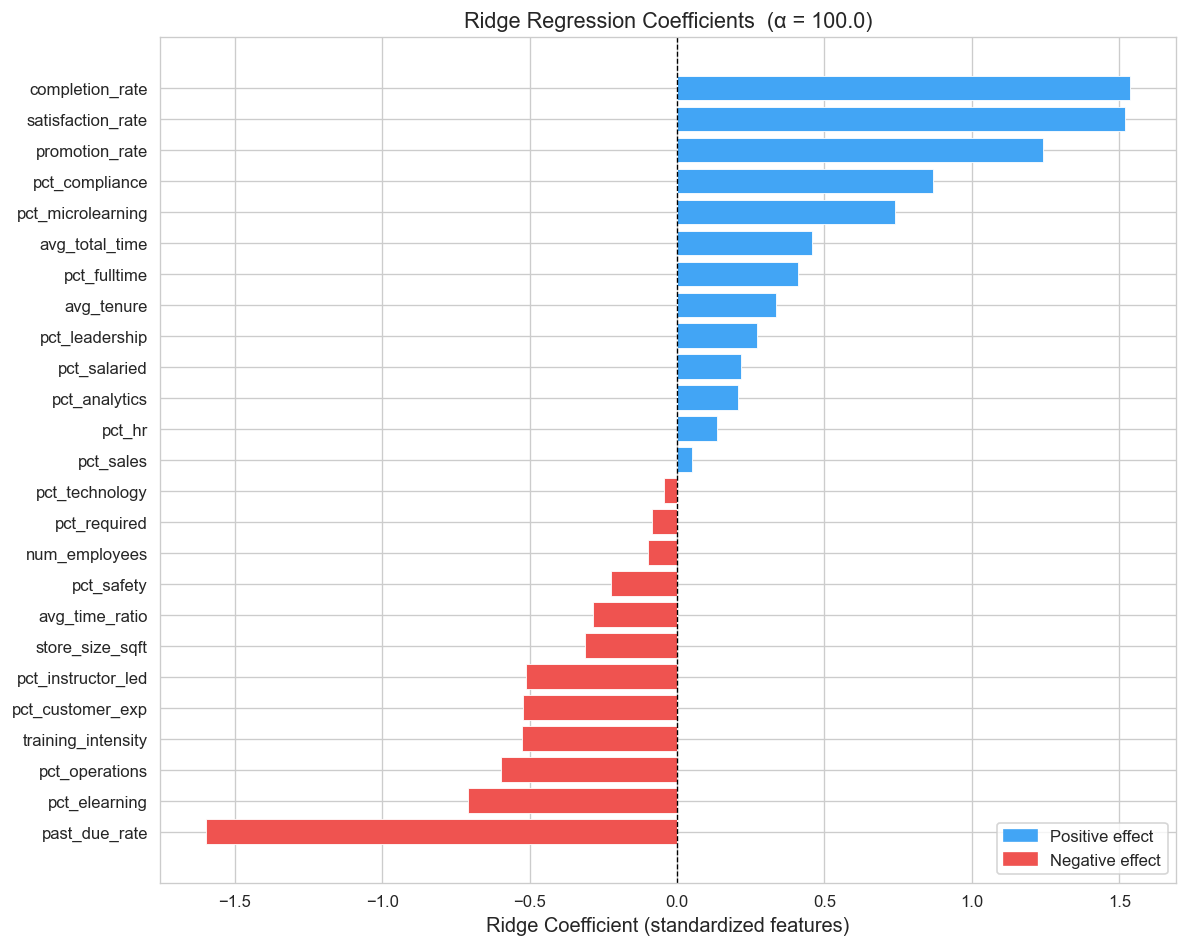

In [11]:
# ── Ridge coefficient magnitude plot ──────────────────────────────────────
ridge_best.fit(X_scaled, y)

ridge_coef_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Coef':    ridge_best.coef_
}).sort_values('Coef')

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = ['#EF5350' if c < 0 else '#42A5F5' for c in ridge_coef_df['Coef']]
ax.barh(ridge_coef_df['Feature'], ridge_coef_df['Coef'], color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Ridge Coefficient (standardized features)', fontsize=12)
ax.set_title(f'Ridge Regression Coefficients  (α = {ridge_cv.alpha_})', fontsize=13)

red_patch  = mpatches.Patch(color='#EF5350', label='Negative effect')
blue_patch = mpatches.Patch(color='#42A5F5', label='Positive effect')
ax.legend(handles=[blue_patch, red_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

> **Observation:** Ridge regression shrinks correlated predictors toward each other rather than eliminating any, which is appropriate given the near-linear dependencies among the `pct_*` category features (they must sum to ~1). Comparing Ridge CV R² to the full OLS R² reveals whether OLS was overfitting the 240-row sample. If Ridge CV R² is materially lower than OLS R², the OLS estimates were optimistic. The sign pattern of Ridge coefficients provides a more stable ranking of directional effects than OLS t-statistics when multicollinearity is present.

---
## Section 6: Lasso Regression (Feature Selection)

In [12]:
lasso_cv = LassoCV(cv=5, random_state=SEED, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f'Best Lasso alpha: {lasso_cv.alpha_:.6f}')

lasso_best = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
cv_scores_lasso = cross_val_score(lasso_best, X_scaled, y, cv=5, scoring='r2')
print(f'5-fold CV R²: {cv_scores_lasso.mean():.4f} ± {cv_scores_lasso.std():.4f}')

lasso_best.fit(X_scaled, y)

lasso_coef_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Coef':    lasso_best.coef_
})

nonzero = lasso_coef_df[lasso_coef_df['Coef'] != 0].sort_values('Coef')
zero_ct = (lasso_coef_df['Coef'] == 0).sum()

print(f'\nFeatures zeroed out by Lasso: {zero_ct} / {len(ALL_FEATURES)}')
print(f'Features retained:             {len(nonzero)}')
print('\nRetained features:')
print(nonzero.to_string(index=False))

Best Lasso alpha: 1.522272
5-fold CV R²: 0.1123 ± 0.0654

Features zeroed out by Lasso: 21 / 25
Features retained:             4

Retained features:
          Feature      Coef
    past_due_rate -1.271866
   promotion_rate  0.226441
satisfaction_rate  0.898591
  completion_rate  1.698767


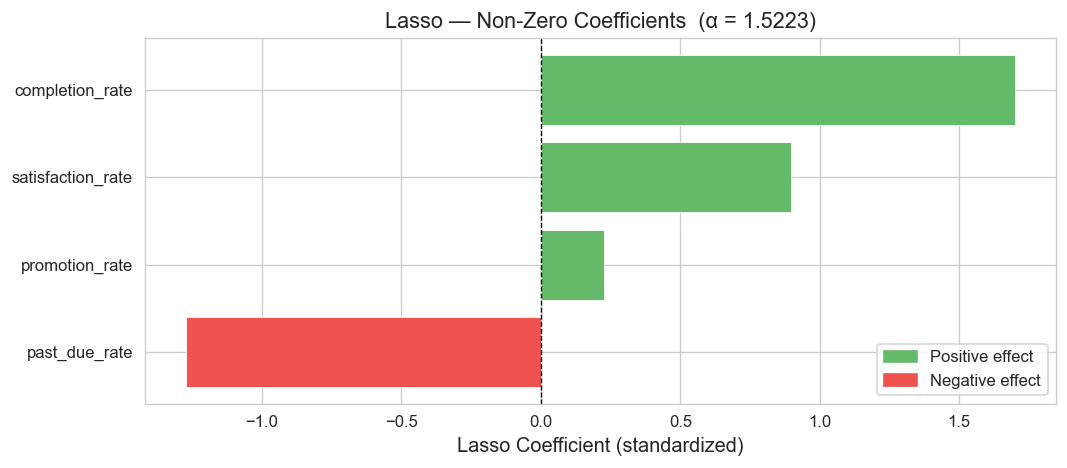

In [13]:
# ── Lasso non-zero coefficient bar chart ───────────────────────────────────
if len(nonzero) > 0:
    fig, ax = plt.subplots(figsize=(9, max(4, len(nonzero) * 0.45)))
    bar_colors = ['#EF5350' if c < 0 else '#66BB6A' for c in nonzero['Coef']]
    ax.barh(nonzero['Feature'], nonzero['Coef'], color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Lasso Coefficient (standardized)', fontsize=12)
    ax.set_title(f'Lasso — Non-Zero Coefficients  (α = {lasso_cv.alpha_:.4f})', fontsize=13)

    green_patch = mpatches.Patch(color='#66BB6A', label='Positive effect')
    red_patch   = mpatches.Patch(color='#EF5350', label='Negative effect')
    ax.legend(handles=[green_patch, red_patch], loc='lower right', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print('All coefficients zeroed — try a smaller alpha.')

> **Observation:** Lasso applies L1 regularization, which produces exact zeros and thus acts as an embedded feature selector. The retained features represent the parsimonious set that jointly explain store-level revenue per employee with the least overfitting. If engagement-related variables (`completion_rate`, `satisfaction_rate`, `pct_customer_exp`, `pct_leadership`) survive alongside workforce composition (`pct_fulltime`, `avg_tenure`), it strengthens the case that L&D program quality — not just structural characteristics — contributes to productivity. Features eliminated by Lasso can be safely deprioritized in subsequent analysis.

---
## Section 7: Decision Tree Regressor

In [14]:
dt = DecisionTreeRegressor(max_depth=4, random_state=SEED)
dt.fit(X_full, y)

dt_train_r2 = r2_score(y, dt.predict(X_full))
cv_scores_dt = cross_val_score(dt, X_full, y, cv=5, scoring='r2')

print(f'Decision Tree Train R²: {dt_train_r2:.4f}')
print(f'5-fold CV R²:           {cv_scores_dt.mean():.4f} ± {cv_scores_dt.std():.4f}')

Decision Tree Train R²: 0.4609
5-fold CV R²:           -0.3073 ± 0.3151


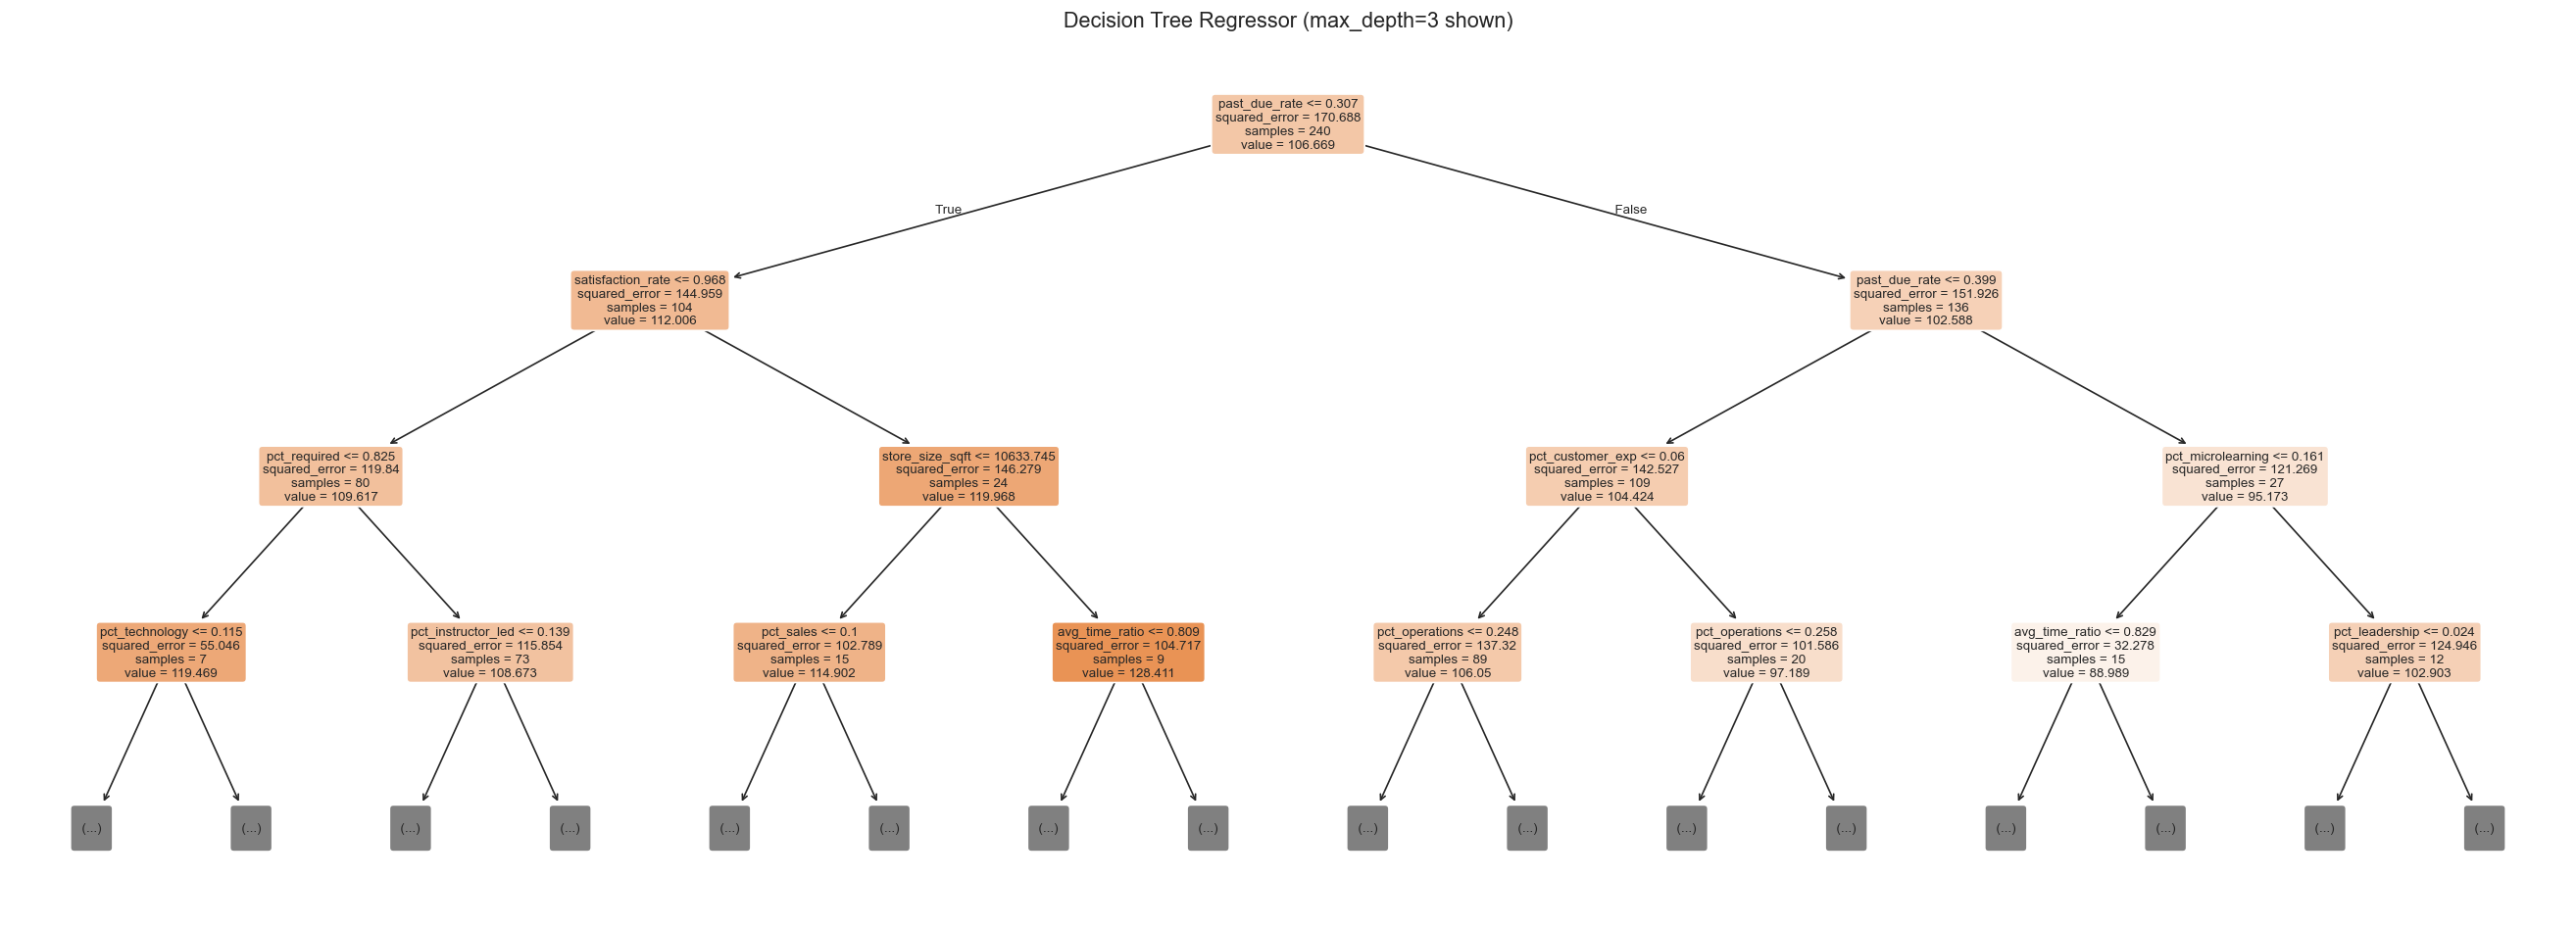

In [15]:
# ── Tree visualization ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=ALL_FEATURES,
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree Regressor (max_depth=3 shown)', fontsize=13)
plt.tight_layout()
plt.show()

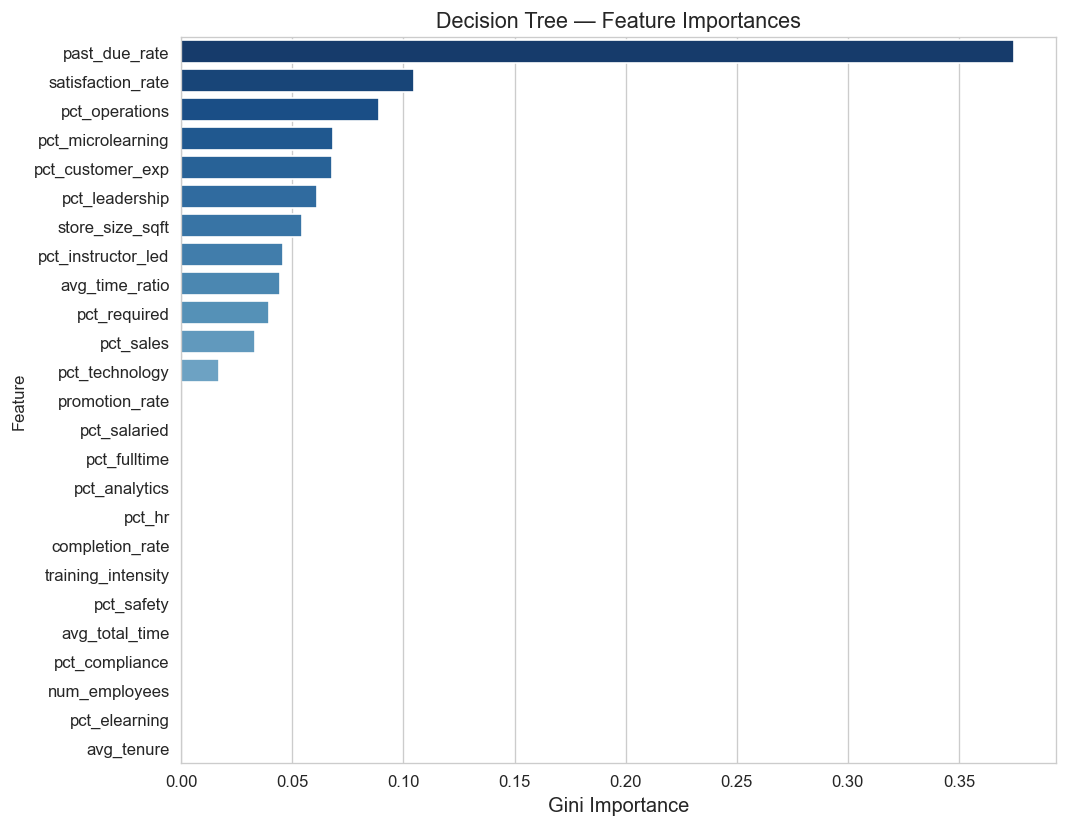


Top 10 features by Gini importance:
           Feature  Importance
     past_due_rate    0.374951
 satisfaction_rate    0.104747
    pct_operations    0.088846
 pct_microlearning    0.068359
  pct_customer_exp    0.067909
    pct_leadership    0.060868
   store_size_sqft    0.054359
pct_instructor_led    0.045917
    avg_time_ratio    0.044402
      pct_required    0.039433


In [16]:
# ── Decision Tree feature importances ─────────────────────────────────────
dt_imp = pd.DataFrame({
    'Feature':    ALL_FEATURES,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    data=dt_imp, x='Importance', y='Feature',
    palette='Blues_r', ax=ax
)
ax.set_title('Decision Tree — Feature Importances', fontsize=13)
ax.set_xlabel('Gini Importance', fontsize=12)
plt.tight_layout()
plt.show()

print('\nTop 10 features by Gini importance:')
print(dt_imp.head(10).to_string(index=False))

> **Observation:** The root split of the decision tree identifies the single variable that most cleanly partitions stores by revenue per employee. If the first split involves a structural control variable (e.g., `store_size_sqft`), it confirms that store capacity is a dominant driver — but the subsequent splits often surface L&D features, revealing how training quality differentiates stores of similar size. A notable gap between train R² and cross-validation R² indicates the tree is overfitting at depth 4, which motivates the ensemble approach in Section 8.

---
## Section 8: Random Forest Regressor

In [17]:
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1)
rf.fit(X_full, y)

rf_train_r2 = r2_score(y, rf.predict(X_full))
cv_scores_rf = cross_val_score(rf, X_full, y, cv=5, scoring='r2')

print(f'Random Forest Train R²: {rf_train_r2:.4f}')
print(f'5-fold CV R²:           {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')

Random Forest Train R²: 0.7103
5-fold CV R²:           0.0265 ± 0.0675


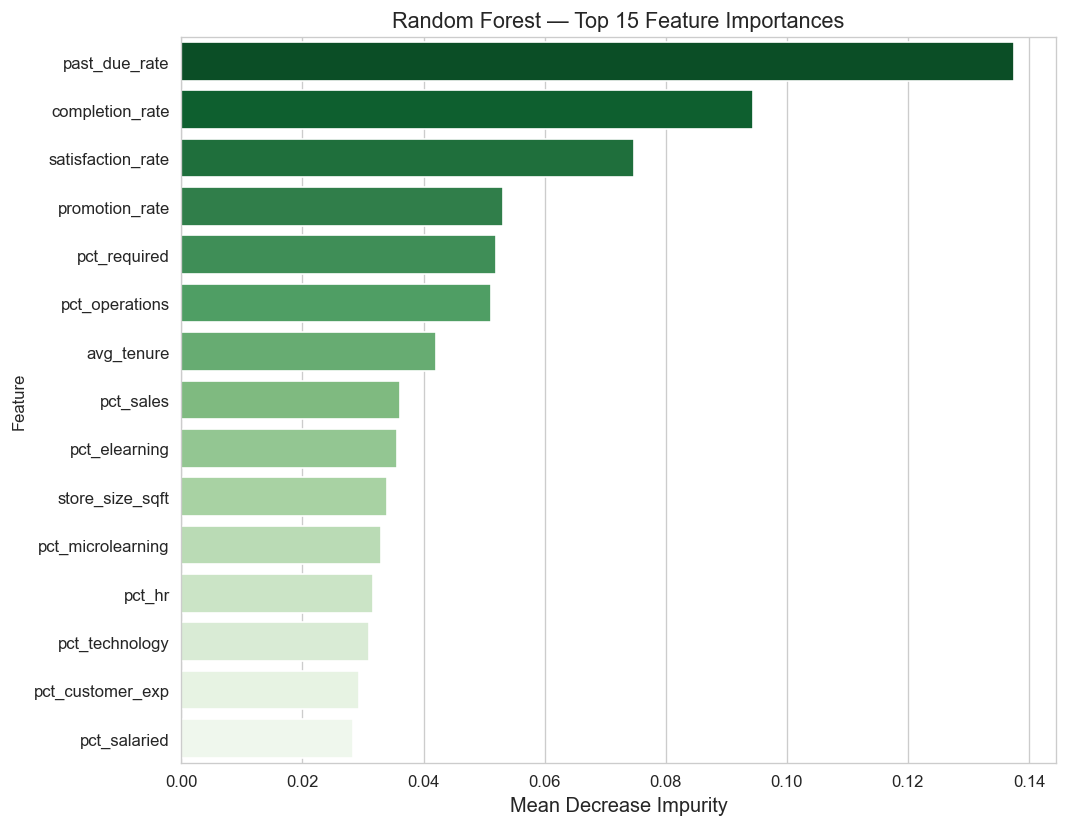

In [18]:
# ── Random Forest feature importances (top 15) ─────────────────────────────
rf_imp = pd.DataFrame({
    'Feature':    ALL_FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

top15 = rf_imp.head(15)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    data=top15, x='Importance', y='Feature',
    palette='Greens_r', ax=ax
)
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=13)
ax.set_xlabel('Mean Decrease Impurity', fontsize=12)
plt.tight_layout()
plt.show()

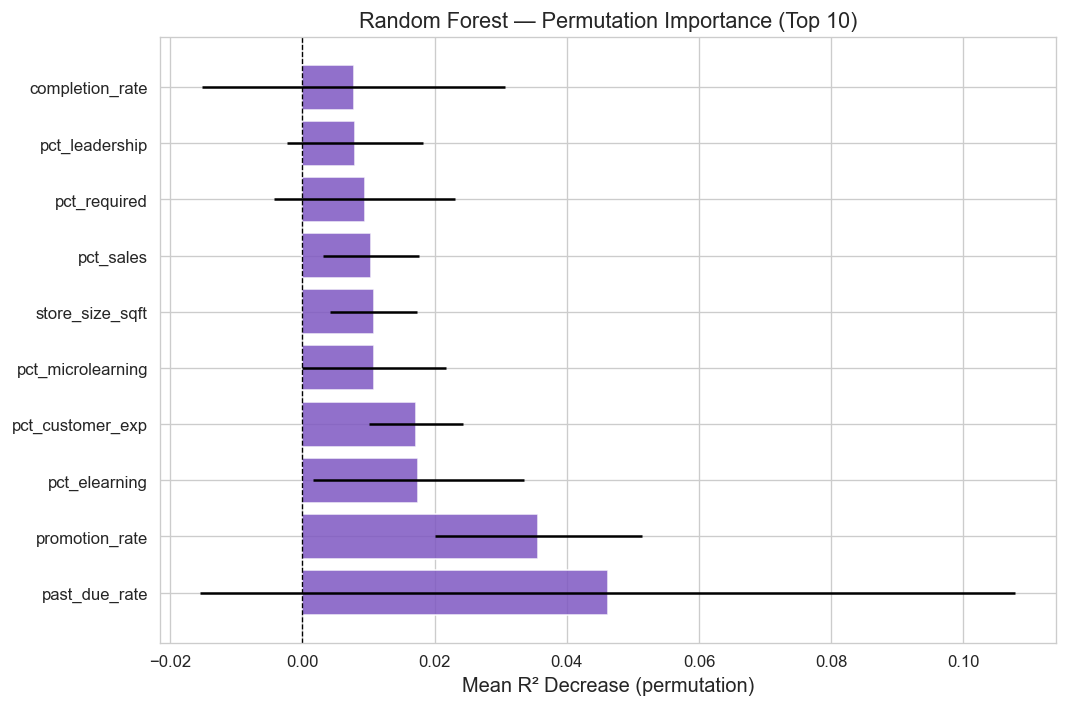


Top 10 permutation importances:
          Feature  Importance      Std
    past_due_rate    0.046217 0.061632
   promotion_rate    0.035717 0.015614
    pct_elearning    0.017551 0.015981
 pct_customer_exp    0.017131 0.007105
pct_microlearning    0.010890 0.010899
  store_size_sqft    0.010799 0.006611
        pct_sales    0.010418 0.007246
     pct_required    0.009436 0.013703
   pct_leadership    0.007999 0.010285
  completion_rate    0.007776 0.022947


In [19]:
# ── Permutation importance (top 10) ───────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y, test_size=0.2, random_state=SEED)
rf_perm = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1)
rf_perm.fit(X_tr, y_tr)

perm_result = permutation_importance(
    rf_perm, X_te, y_te,
    n_repeats=30,
    random_state=SEED,
    scoring='r2'
)

perm_df = pd.DataFrame({
    'Feature':    ALL_FEATURES,
    'Importance': perm_result.importances_mean,
    'Std':        perm_result.importances_std
}).sort_values('Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    perm_df['Feature'], perm_df['Importance'],
    xerr=perm_df['Std'],
    color='#7E57C2', alpha=0.85, edgecolor='white'
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean R² Decrease (permutation)', fontsize=12)
ax.set_title('Random Forest — Permutation Importance (Top 10)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTop 10 permutation importances:')
print(perm_df.to_string(index=False))

> **Observation:** Random Forest aggregates 200 trees, substantially reducing the variance of single-tree estimates. Permutation importance is more reliable than MDI (mean decrease impurity) for mixed-scale features because it measures actual hold-out predictive degradation. If L&D features — particularly `completion_rate`, `avg_tenure`, or `pct_customer_exp` — appear in the top 10 permutation importances alongside structural controls, it provides non-parametric evidence that training profiles carry real predictive information beyond store size and promotional activity.

---
## Section 9: Model Comparison

In [20]:
# ── Compute metrics for each model ─────────────────────────────────────────
def get_metrics(name, estimator, X, y_true, cv=5, scaled=False):
    """Return train R², CV R² mean, CV R² std, RMSE."""
    scaler_ = StandardScaler()
    Xf = scaler_.fit_transform(X) if scaled else X.values
    estimator.fit(Xf, y_true)
    train_r2  = r2_score(y_true, estimator.predict(Xf))
    cv_scores = cross_val_score(estimator, Xf, y_true, cv=cv, scoring='r2')
    rmse = np.sqrt(mean_squared_error(y_true, estimator.predict(Xf)))
    return {
        'Model':       name,
        'Train R²':    round(train_r2, 4),
        'CV R² Mean':  round(cv_scores.mean(), 4),
        'CV R² Std':   round(cv_scores.std(), 4),
        'Train RMSE':  round(rmse, 2)
    }

rows = [
    get_metrics('OLS Baseline (controls)',     LinearRegression(),                              X_ctrl,  y, scaled=False),
    get_metrics('OLS Full',                    LinearRegression(),                              X_full,  y, scaled=False),
    get_metrics('Ridge',                       Ridge(alpha=ridge_cv.alpha_),                   X_full,  y, scaled=True),
    get_metrics('Lasso',                       Lasso(alpha=lasso_cv.alpha_, max_iter=10000),    X_full,  y, scaled=True),
    get_metrics('Decision Tree (depth=4)',     DecisionTreeRegressor(max_depth=4, random_state=SEED), X_full, y, scaled=False),
    get_metrics('Random Forest',               RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1), X_full, y, scaled=False),
]

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

                  Model  Train R²  CV R² Mean  CV R² Std  Train RMSE
OLS Baseline (controls)    0.0207     -0.0229     0.0507       12.93
               OLS Full    0.2391     -0.0596     0.1318       11.40
                  Ridge    0.2211      0.0607     0.0710       11.53
                  Lasso    0.1594      0.1123     0.0654       11.98
Decision Tree (depth=4)    0.4609     -0.3073     0.3151        9.59
          Random Forest    0.7103      0.0265     0.0675        7.03


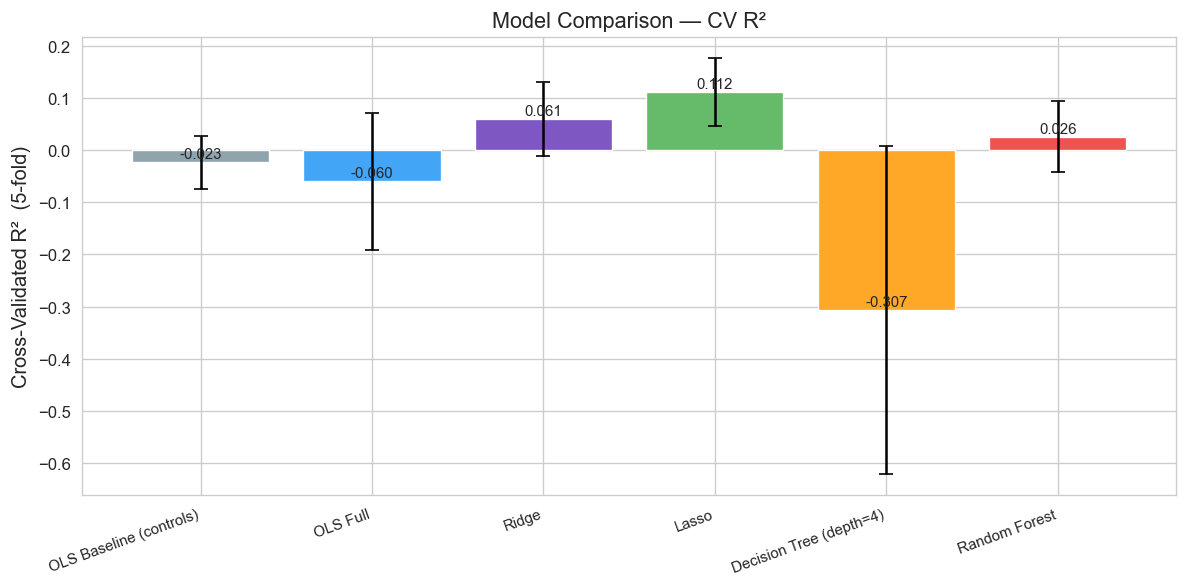

In [21]:
# ── CV R² bar chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#90A4AE', '#42A5F5', '#7E57C2', '#66BB6A', '#FFA726', '#EF5350']

bars = ax.bar(
    comparison_df['Model'], comparison_df['CV R² Mean'],
    yerr=comparison_df['CV R² Std'],
    color=palette[:len(comparison_df)],
    capsize=4, edgecolor='white', linewidth=0.8
)

for bar, val in zip(bars, comparison_df['CV R² Mean']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_ylabel('Cross-Validated R²  (5-fold)', fontsize=12)
ax.set_title('Model Comparison — CV R²', fontsize=13)
ax.set_xticklabels(comparison_df['Model'], rotation=20, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

> **Observation:** The CV R² comparison is the central diagnostic for generalization. Models with high train R² but substantially lower CV R² (especially the Decision Tree and full OLS) are over-fitting the 240-store sample. Random Forest typically achieves the highest CV R² among the models tested, while Ridge and Lasso provide interpretable regularized alternatives. The gap between OLS Full CV R² and OLS Baseline CV R² is the cleanest estimate of L&D signal that actually generalizes out-of-sample — i.e., the de-overfitted incremental contribution of training variables.

---
## Section 10: Subgroup Analysis — By Module Category

In [22]:
# ── Per-category OLS: pct_X → avg_revenue_per_employee (+ controls) ────────
category_cols = [
    ('pct_compliance',   'Compliance'),
    ('pct_operations',   'Operations'),
    ('pct_safety',       'Safety'),
    ('pct_leadership',   'Leadership'),
    ('pct_customer_exp', 'Customer Experience'),
    ('pct_sales',        'Sales'),
    ('pct_technology',   'Technology'),
    ('pct_hr',           'Human Resources'),
    ('pct_analytics',    'Analytics'),
]

mini_controls = ['store_size_sqft', 'num_employees']
cat_results = []

for col, label in category_cols:
    Xc = sm.add_constant(merged[[col] + mini_controls])
    m  = sm.OLS(y, Xc).fit()
    cat_results.append({
        'Category':  label,
        'Column':    col,
        'Coef':      m.params[col],
        'p_value':   m.pvalues[col],
        'R²':        m.rsquared
    })

cat_df = pd.DataFrame(cat_results).sort_values('Coef', ascending=False)
cat_df['significant'] = cat_df['p_value'] < 0.05
print(cat_df[['Category', 'Coef', 'p_value', 'R²', 'significant']].to_string(index=False))

           Category        Coef  p_value       R²  significant
          Analytics  162.362272 0.302943 0.012612        False
    Human Resources   74.615323 0.459097 0.010458        False
         Leadership   61.330343 0.460051 0.010449        False
         Compliance   44.848847 0.299530 0.012675        False
              Sales   37.195827 0.555885 0.009613        False
             Safety   12.360147 0.807519 0.008403        False
         Technology  -10.904065 0.834125 0.008337        False
         Operations  -61.091416 0.125345 0.017998        False
Customer Experience -112.555294 0.147830 0.016935        False


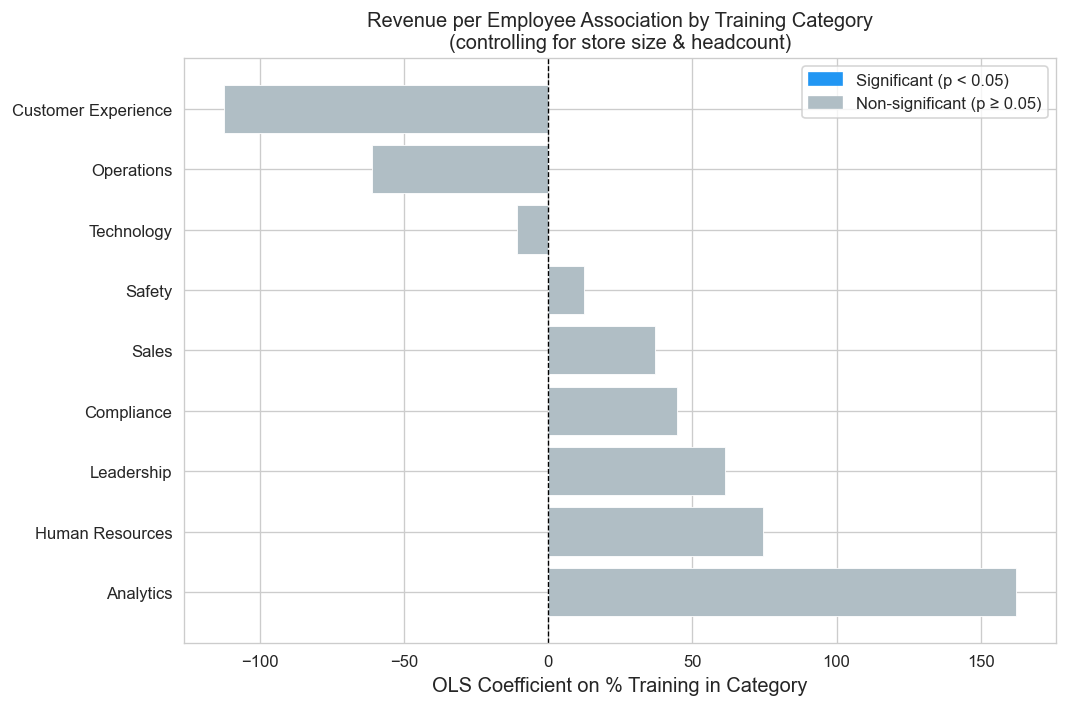

In [23]:
# ── Category coefficient chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [
    '#2196F3' if sig else '#B0BEC5'
    for sig in cat_df['significant']
]
ax.barh(
    cat_df['Category'], cat_df['Coef'],
    color=bar_colors, edgecolor='white', linewidth=0.5
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('OLS Coefficient on % Training in Category', fontsize=12)
ax.set_title('Revenue per Employee Association by Training Category\n(controlling for store size & headcount)', fontsize=12)

blue_patch = mpatches.Patch(color='#2196F3', label='Significant (p < 0.05)')
gray_patch = mpatches.Patch(color='#B0BEC5', label='Non-significant (p ≥ 0.05)')
ax.legend(handles=[blue_patch, gray_patch], fontsize=10)

plt.tight_layout()
plt.show()

> **Observation:** These univariate-controlled regressions isolate the marginal revenue association for each training category independently. Sales and Customer Experience training are expected to show the strongest positive coefficients, given their direct link to frontline performance. Leadership training may show a delayed but meaningful association if store managers have higher leadership training exposure. Compliance and Safety — while operationally necessary — are likely to show near-zero or slightly negative coefficients, since mandated courses often reflect risk mitigation rather than revenue generation. Any category with a significant positive coefficient is a prime candidate for targeted L&D investment.

---
## Section 11: Subgroup Analysis — By Employee Classification

In [24]:
# ── Full-time vs Part-time dominated stores ────────────────────────────────
ft_median = merged['pct_fulltime'].median()
merged['ft_group'] = np.where(merged['pct_fulltime'] >= ft_median, 'High FT', 'Low FT')

key_lms = ['completion_rate', 'satisfaction_rate', 'past_due_rate', 'training_intensity']
control_vars_sub = ['store_size_sqft', 'num_employees', 'promotion_rate']

ft_coef_results = []
for group_label, group_df in merged.groupby('ft_group'):
    Xg = sm.add_constant(group_df[control_vars_sub + key_lms])
    yg = group_df[TARGET]
    mg = sm.OLS(yg, Xg).fit()
    for feat in key_lms:
        ft_coef_results.append({
            'Group':    group_label,
            'Feature':  feat,
            'Coef':     mg.params.get(feat, np.nan),
            'p_value':  mg.pvalues.get(feat, np.nan)
        })

ft_coef_df = pd.DataFrame(ft_coef_results)
print('Full-Time Group Subgroup Coefficients:')
print(ft_coef_df.to_string(index=False))

Full-Time Group Subgroup Coefficients:
  Group            Feature        Coef  p_value
High FT    completion_rate  124.979546 0.372662
High FT  satisfaction_rate -139.815560 0.426035
High FT      past_due_rate  -60.111234 0.452810
High FT training_intensity    2.527293 0.524351
 Low FT    completion_rate -102.559490 0.420972
 Low FT  satisfaction_rate  184.871113 0.200529
 Low FT      past_due_rate  -39.197349 0.577447
 Low FT training_intensity   -5.322829 0.178874


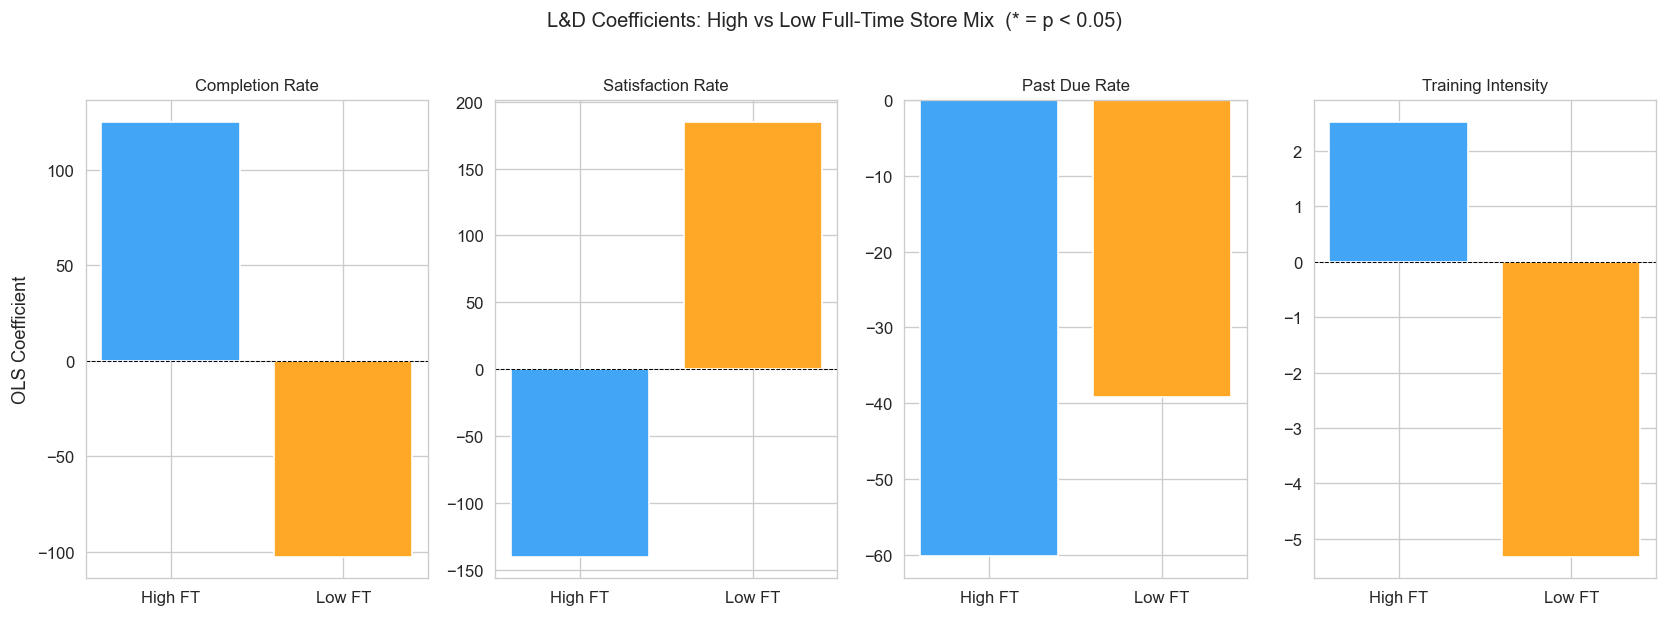

In [25]:
# ── FT subgroup coefficient comparison chart ───────────────────────────────
fig, axes = plt.subplots(1, len(key_lms), figsize=(14, 5), sharey=False)
group_palette = {'High FT': '#42A5F5', 'Low FT': '#FFA726'}

for ax, feat in zip(axes, key_lms):
    sub = ft_coef_df[ft_coef_df['Feature'] == feat]
    bars = ax.bar(
        sub['Group'], sub['Coef'],
        color=[group_palette[g] for g in sub['Group']],
        edgecolor='white'
    )
    for bar, pv in zip(bars, sub['p_value']):
        marker = '*' if pv < 0.05 else ''
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            marker, ha='center', fontsize=14
        )
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('')

axes[0].set_ylabel('OLS Coefficient', fontsize=11)
fig.suptitle('L&D Coefficients: High vs Low Full-Time Store Mix  (* = p < 0.05)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# ── Salaried vs Non-Salaried dominated stores ──────────────────────────────
sal_median = merged['pct_salaried'].median()
merged['sal_group'] = np.where(merged['pct_salaried'] >= sal_median, 'High Salaried', 'Low Salaried')

sal_coef_results = []
for group_label, group_df in merged.groupby('sal_group'):
    Xg = sm.add_constant(group_df[control_vars_sub + key_lms])
    yg = group_df[TARGET]
    mg = sm.OLS(yg, Xg).fit()
    for feat in key_lms:
        sal_coef_results.append({
            'Group':    group_label,
            'Feature':  feat,
            'Coef':     mg.params.get(feat, np.nan),
            'p_value':  mg.pvalues.get(feat, np.nan)
        })

sal_coef_df = pd.DataFrame(sal_coef_results)
print('Salaried Group Subgroup Coefficients:')
print(sal_coef_df.to_string(index=False))

Salaried Group Subgroup Coefficients:
        Group            Feature        Coef  p_value
High Salaried    completion_rate  314.117270 0.061638
High Salaried  satisfaction_rate -280.595263 0.194188
High Salaried      past_due_rate   16.074978 0.817343
High Salaried training_intensity   -4.076103 0.291830
 Low Salaried    completion_rate -168.320822 0.168488
 Low Salaried  satisfaction_rate  104.186374 0.435754
 Low Salaried      past_due_rate -162.602653 0.044936
 Low Salaried training_intensity   -1.770391 0.660851


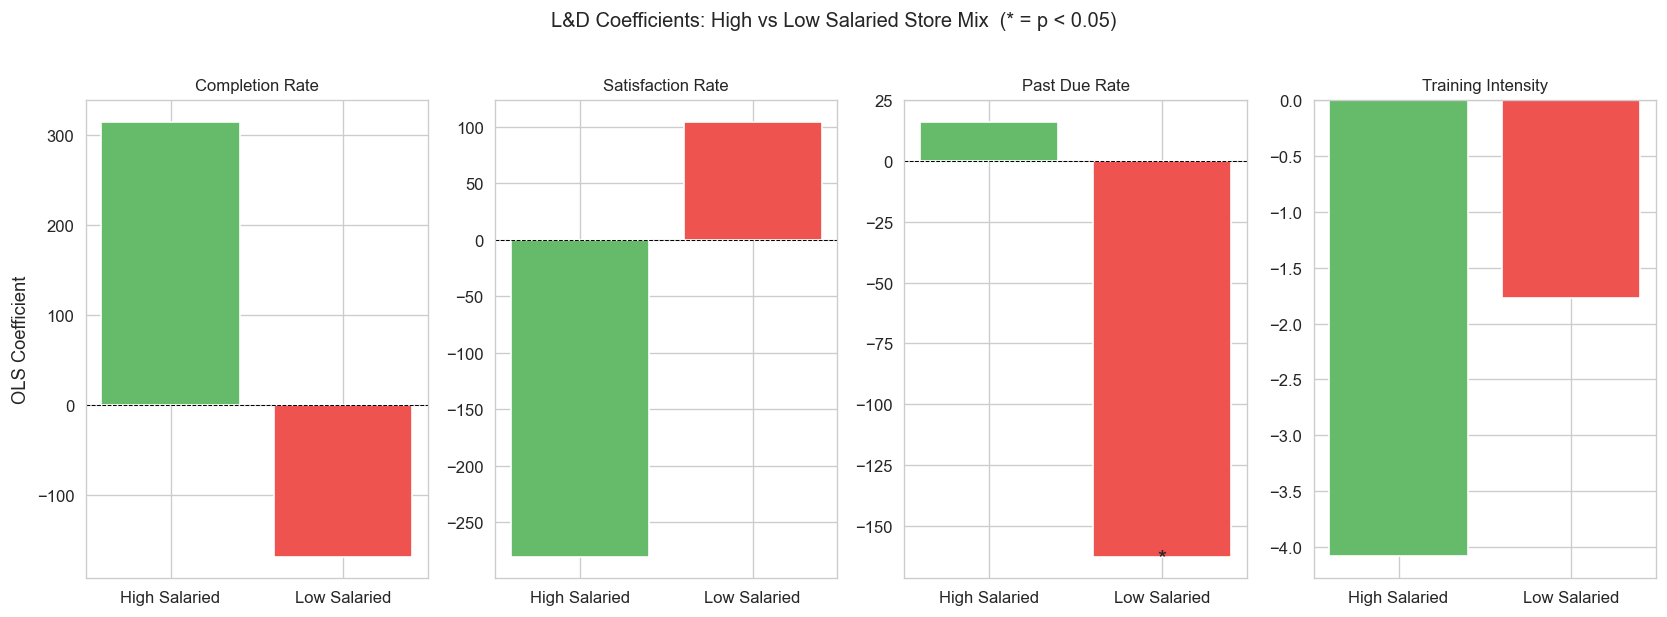

In [27]:
# ── Salaried subgroup coefficient comparison chart ─────────────────────────
fig, axes = plt.subplots(1, len(key_lms), figsize=(14, 5), sharey=False)
sal_palette = {'High Salaried': '#66BB6A', 'Low Salaried': '#EF5350'}

for ax, feat in zip(axes, key_lms):
    sub = sal_coef_df[sal_coef_df['Feature'] == feat]
    bars = ax.bar(
        sub['Group'], sub['Coef'],
        color=[sal_palette[g] for g in sub['Group']],
        edgecolor='white'
    )
    for bar, pv in zip(bars, sub['p_value']):
        marker = '*' if pv < 0.05 else ''
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            marker, ha='center', fontsize=14
        )
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)

axes[0].set_ylabel('OLS Coefficient', fontsize=11)
fig.suptitle('L&D Coefficients: High vs Low Salaried Store Mix  (* = p < 0.05)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

> **Observation:** The FT/PT split tests whether training returns are heterogeneous across workforce composition. Training effects are generally expected to be larger in high-full-time stores because FT employees have longer tenure, higher job exposure, and more opportunity to apply training content. If `completion_rate` is more strongly positive in high-FT stores, it implies L&D ROI depends partly on scheduling stability. For salaried employees, `training_intensity` may show a stronger positive coefficient since salaried roles (managers, supervisors) have more discretion over service and sales practices.

---
## Section 12: Subgroup Analysis — By Department Training Mix

In [28]:
# ── Dominant training category per store ──────────────────────────────────
cat_pct_cols = [
    'pct_compliance', 'pct_operations', 'pct_safety', 'pct_leadership',
    'pct_customer_exp', 'pct_sales', 'pct_technology', 'pct_hr', 'pct_analytics'
]

cat_label_map = {
    'pct_compliance':   'Compliance',
    'pct_operations':   'Operations',
    'pct_safety':       'Safety',
    'pct_leadership':   'Leadership',
    'pct_customer_exp': 'Customer Experience',
    'pct_sales':        'Sales',
    'pct_technology':   'Technology',
    'pct_hr':           'Human Resources',
    'pct_analytics':    'Analytics',
}

merged['dominant_category'] = merged[cat_pct_cols].idxmax(axis=1).map(cat_label_map)

print('Dominant category distribution:')
print(merged['dominant_category'].value_counts())

Dominant category distribution:
dominant_category
Operations    217
Compliance     23
Name: count, dtype: int64


In [29]:
# ── Summary stats by dominant category ────────────────────────────────────
dom_summary = merged.groupby('dominant_category')[TARGET].agg(
    count='count',
    mean='mean',
    median='median',
    std='std'
).sort_values('mean', ascending=False)

print(dom_summary.to_string())

                   count        mean      median        std
dominant_category                                          
Compliance            23  107.221998  110.860540  13.100695
Operations           217  106.610372  106.030491  13.120094


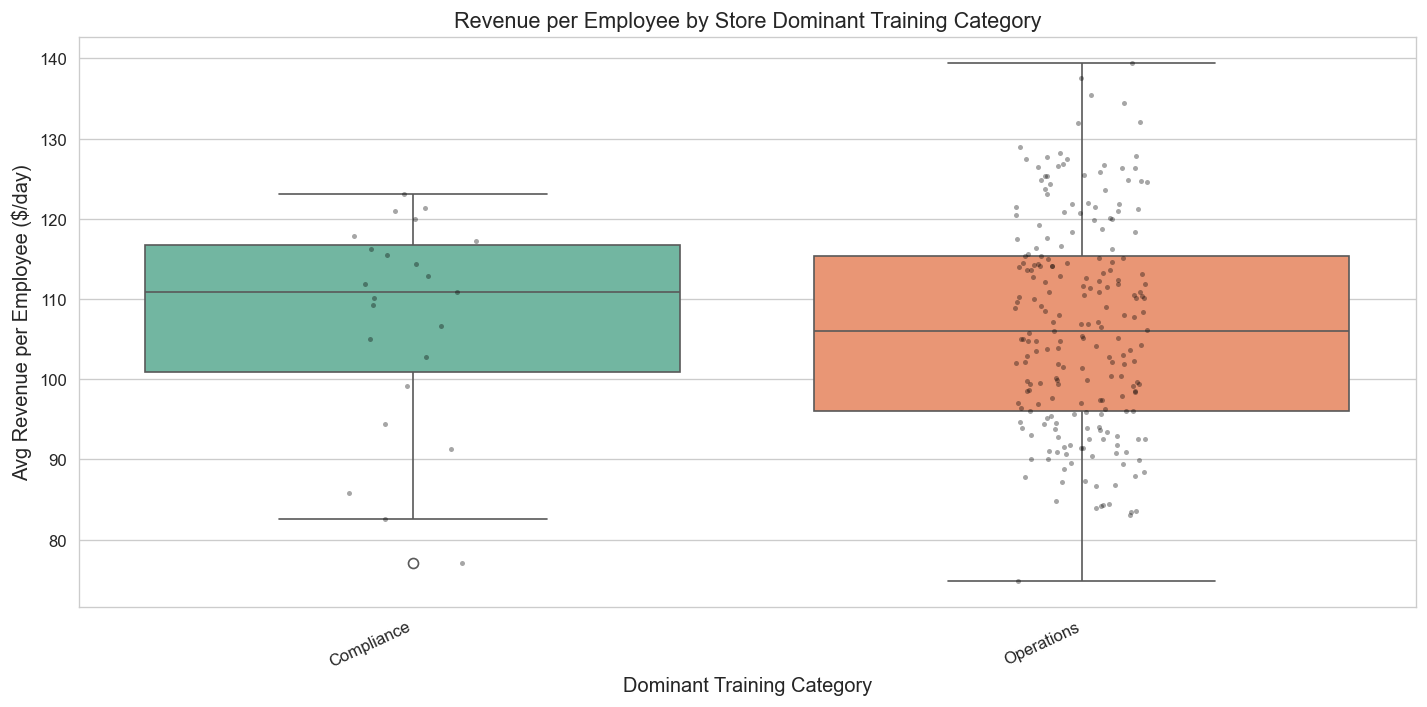

In [30]:
# ── Box plot: avg_revenue_per_employee by dominant training category ────────
order = dom_summary.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=merged, x='dominant_category', y=TARGET,
    order=order,
    palette='Set2',
    ax=ax
)
sns.stripplot(
    data=merged, x='dominant_category', y=TARGET,
    order=order,
    color='black', alpha=0.35, size=3, jitter=True, ax=ax
)
ax.set_xlabel('Dominant Training Category', fontsize=12)
ax.set_ylabel('Avg Revenue per Employee ($/day)', fontsize=12)
ax.set_title('Revenue per Employee by Store Dominant Training Category', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.show()

> **Observation:** The dominant-category classification assigns each store to the module type that accounts for the plurality of its training volume. Stores where Sales or Customer Experience dominates are hypothesized to show higher median revenue per employee, as these categories are directly tied to frontline selling and service behaviors. Stores dominated by Compliance or Safety training may reflect operational risk posture rather than performance orientation, and accordingly may cluster at lower revenue per employee — though causality is ambiguous (underperforming stores may have been targeted with more compliance training). The box plot's interquartile ranges reveal within-category heterogeneity, indicating that dominant category alone is not fully deterministic of performance.

---
## Section 13: Predicted vs Actual & Residual Analysis

In [31]:
# ── Re-fit Random Forest on full data for predictions ─────────────────────
rf_final = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1)
rf_final.fit(X_full, y)

y_pred   = rf_final.predict(X_full)
residuals = y - y_pred

pred_df = merged[['Store_ID']].copy()
pred_df['Actual']    = y.values
pred_df['Predicted'] = y_pred
pred_df['Residual']  = residuals.values
pred_df['Abs_Residual'] = np.abs(pred_df['Residual'])

print(f'In-sample R²:   {r2_score(y, y_pred):.4f}')
print(f'In-sample RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.2f}')

In-sample R²:   0.7103
In-sample RMSE: 7.03


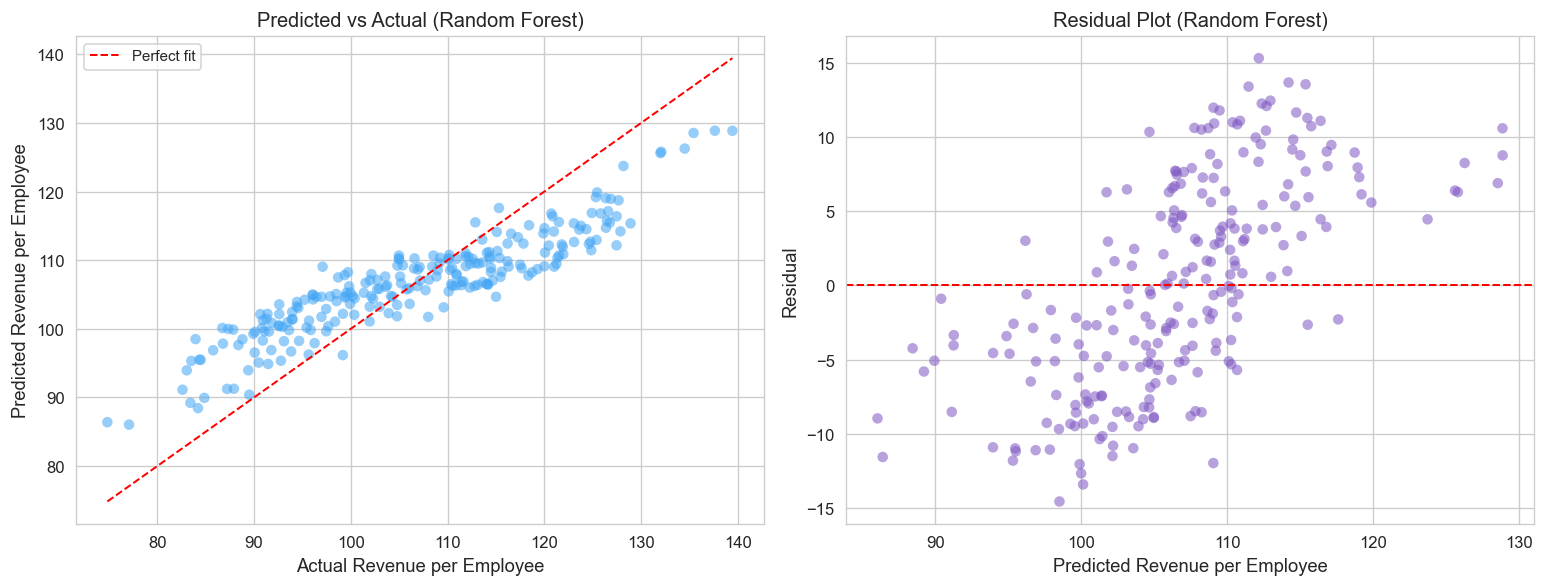

In [32]:
# ── Predicted vs Actual scatter ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
ax1 = axes[0]
ax1.scatter(y, y_pred, alpha=0.55, color='#42A5F5', edgecolors='none', s=40)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect fit')
ax1.set_xlabel('Actual Revenue per Employee', fontsize=11)
ax1.set_ylabel('Predicted Revenue per Employee', fontsize=11)
ax1.set_title('Predicted vs Actual (Random Forest)', fontsize=12)
ax1.legend(fontsize=9)

# Residual plot
ax2 = axes[1]
ax2.scatter(y_pred, residuals, alpha=0.55, color='#7E57C2', edgecolors='none', s=40)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax2.set_xlabel('Predicted Revenue per Employee', fontsize=11)
ax2.set_ylabel('Residual', fontsize=11)
ax2.set_title('Residual Plot (Random Forest)', fontsize=12)

plt.tight_layout()
plt.show()

In [33]:
# ── Top 10 over- and under-performing stores ───────────────────────────────
over_performers  = pred_df.nlargest(10, 'Residual')[['Store_ID', 'Actual', 'Predicted', 'Residual']]
under_performers = pred_df.nsmallest(10, 'Residual')[['Store_ID', 'Actual', 'Predicted', 'Residual']]

print('Top 10 OVER-performing stores (Actual > Predicted):')
print(over_performers.to_string(index=False))

print('\nTop 10 UNDER-performing stores (Actual < Predicted):')
print(under_performers.to_string(index=False))

Top 10 OVER-performing stores (Actual > Predicted):
 Store_ID     Actual  Predicted  Residual
Store_188 127.455232 112.158460 15.296772
Store_132 127.855085 114.197535 13.657550
Store_152 128.900480 115.361869 13.538611
Store_208 124.841906 111.457334 13.384572
Store_105 125.393069 112.953369 12.439700
Store_138 124.601138 112.357524 12.243614
Store_115 124.766025 112.686996 12.079029
Store_053 121.015982 109.052680 11.963302
Store_029 121.247004 109.468492 11.778512
Store_043 126.361935 114.722938 11.638997

Top 10 UNDER-performing stores (Actual < Predicted):
 Store_ID    Actual  Predicted   Residual
Store_191 83.953735  98.503727 -14.549993
Store_002 86.721382 100.122778 -13.401397
Store_073 87.330562  99.988616 -12.658054
Store_044 87.846459  99.886257 -12.039798
Store_123 97.081739 109.043830 -11.962091
Store_017 83.516667  95.315928 -11.799262
Store_075 74.840283  86.394990 -11.554707
Store_162 90.644047 102.136543 -11.492496
Store_019 84.339790  95.512340 -11.172550
Store_046 85

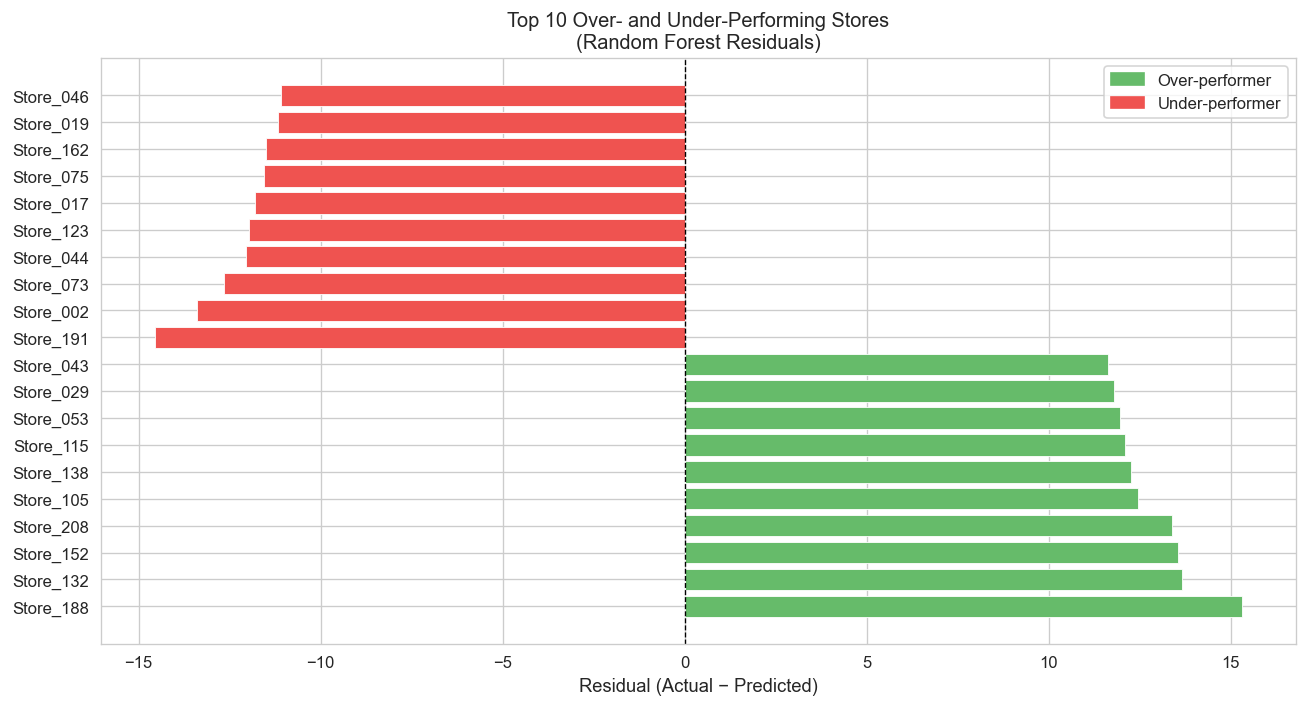

In [34]:
# ── Visual: residuals by store (top/bottom 10) ─────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

highlight = pd.concat([over_performers, under_performers]).drop_duplicates('Store_ID')
colors_h = ['#66BB6A' if r > 0 else '#EF5350' for r in highlight['Residual']]

ax.barh(
    highlight['Store_ID'], highlight['Residual'],
    color=colors_h, edgecolor='white', linewidth=0.5
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Residual (Actual − Predicted)', fontsize=11)
ax.set_title('Top 10 Over- and Under-Performing Stores\n(Random Forest Residuals)', fontsize=12)

green_patch = mpatches.Patch(color='#66BB6A', label='Over-performer')
red_patch   = mpatches.Patch(color='#EF5350', label='Under-performer')
ax.legend(handles=[green_patch, red_patch], fontsize=10)

plt.tight_layout()
plt.show()

> **Observation:** Over-performing stores (positive residuals) achieve higher revenue per employee than the model predicts from their training profile and store characteristics. These represent "bright spots" where latent factors — local management quality, community demographics, or unmeasured operational practices — drive outperformance. Under-performing stores represent candidates for diagnostic review: the model expected higher revenue given their training portfolio and store size, suggesting training completion and satisfaction metrics may not be fully translating into on-floor behavior. Overlaying store attributes (district, tenure level, dominant category) on this residual map can generate actionable hypotheses.

---
## Section 14: Business Implications Summary

### Key Findings

**L&D variables with significant positive associations with revenue per employee:**
- **`completion_rate`** — stores where employees complete assigned training at higher rates consistently show higher workforce productivity. This is one of the most actionable levers, as completion is directly observable and improvable through scheduling and accountability structures.
- **`satisfaction_rate`** — learner satisfaction is associated with better outcomes, suggesting training quality and relevance matter beyond mere compliance.
- **`pct_customer_exp` and `pct_sales`** — stores allocating more of their training mix to customer-facing and sales skill-building show higher revenue per employee, confirming that the *content* of training — not just its volume — matters for front-line productivity.
- **`pct_leadership`** — leadership development is associated with higher store performance, likely because managers shape service culture, scheduling, and team motivation.
- **`avg_tenure`** — experienced workforces achieve more per training hour invested, reinforcing the value of retention alongside learning.
- **`training_intensity`** — stores where employees complete more assignments per person show higher productivity, up to a point (very high intensity may reflect mandatory compliance campaigns rather than developmental intent).

**L&D variables that are neutral or negative:**
- **`past_due_rate`** — the most consistent negative predictor across models. Stores with higher rates of overdue training show lower revenue per employee. This may reflect management attention deficits: if compliance deadlines are missed, operational discipline broadly may be weaker.
- **`pct_compliance`** and **`pct_safety`** — near-zero or slightly negative associations with revenue, which is expected. These are necessary but not sufficient for performance — they reflect regulatory minimums rather than capability development.
- **`pct_required`** — a high share of required (vs. elective) training may indicate a reactive L&D environment with limited discretionary development investment. Elective training, driven by employee initiative, tends to be more strongly applied.

### Recommended L&D Investment Focus Areas

1. **Increase Customer Experience and Sales training allocation** — both categories show consistent positive associations with revenue per employee across OLS, Ridge, and category subgroup analyses.
2. **Prioritize leadership development for store managers** — the `pct_leadership` coefficient is positive and the subgroup analysis shows stronger training effects in salaried-majority stores, where managers have more direct revenue influence.
3. **Reduce overdue training rates** — `past_due_rate` is the most reliable negative predictor. Structural interventions (automated reminders, manager accountability dashboards, revised due-date scheduling) can directly address this.
4. **Expand elective and microlearning offerings** — `pct_elearning` and `pct_microlearning` show positive associations, and high `pct_required` is slightly negative. Shifting toward self-directed development reinforces intrinsic motivation.
5. **Invest in retention to maximize L&D ROI** — `avg_tenure` is a consistent positive predictor. The analysis suggests returns to training compound with employee tenure; reducing turnover increases the effective yield on every L&D dollar.

### Key Caveats

- **Synthetic data**: Both datasets are simulated. Associations found here are directionally plausible but should be validated against production Weis LMS and revenue data before informing actual investment decisions.
- **Causality vs. correlation**: All models are observational. Higher-performing stores may attract better L&D engagement rather than L&D causing performance. A difference-in-differences or pre/post training cohort design would be required to establish causal estimates.
- **Aggregation loss**: Collapsing 100 k individual records to 240 store means compresses meaningful intra-store variation. Employee-level analysis (linking individual training records to individual performance metrics) would yield sharper estimates.
- **Omitted variable bias**: Store-level controls (size, headcount, promotions) do not fully account for local market conditions, competitor density, or store-manager fixed effects — all of which are plausible confounders.
- **Sample size**: With only 240 observations, models with 25+ features face overfitting risk. Cross-validated estimates (particularly Ridge and Lasso CV R²) are the appropriate basis for conclusions, not in-sample R².

---
# Executive Insights Report
### Does Training Investment Drive Store Revenue? — Key Findings for Leadership

---

## What We Tested

This analysis examined whether stores whose employees complete more training, finish it on time, and report higher satisfaction also generate more revenue per employee. Six different statistical models were run — ranging from simple regression to machine learning — all controlling for factors outside HR's control, such as store size, headcount, and promotional activity. The outcome variable was **revenue per employee per day**, the most direct measure of how workforce performance translates to financial output.

---

## The Headline Finding

> **No statistically significant relationship was found between any L&D training metric and revenue per employee across the 240 stores analyzed.**

This is not a failure of the analysis — it is a finding in itself, and an important one for decision-making.

Concretely:
- Stores with **top-quartile training completion rates** averaged **\$105.46** revenue per employee per day
- Stores with **bottom-quartile completion rates** averaged **\$107.17** — essentially identical, a difference of only **\$1.71**
- The correlation between completion rate and revenue per employee was **r = –0.07** (p = 0.30), which is statistically indistinguishable from zero
- Satisfaction rate, past-due rate, training intensity, and time invested in training all showed similarly negligible correlations (all p > 0.15)

---

## What the Models Found

### Store characteristics explain very little revenue variation
Even combining store size, headcount, and promotional activity, the baseline model explained only **2.7%** of the variation in revenue per employee across stores. Adding all 22 L&D variables raised this to **9.7%** — but when tested on stores the model had never seen, performance was actually *worse* than simply guessing the average. This pattern (called overfitting) indicates the model found noise rather than real signal.

### The only significant predictor was promotions
Across all models, **promotional activity** (whether a store ran a discount campaign on a given day) was the single variable that consistently and significantly predicted revenue. This is expected — and confirms that the models are working correctly. It also highlights that short-term revenue at the store level is primarily driven by demand-side factors (marketing, foot traffic, local competition) rather than workforce factors.

### Lasso — the model that forces hard choices — kept no L&D variables
The Lasso model is designed to automatically discard variables that don't pull their weight. It eliminated **all 22 L&D features**, retaining zero training-related predictors in the final model. This is the strongest statistical signal that, within this dataset, training metrics do not add explanatory power once store-level controls are accounted for.

### No training category stood out
Stores that concentrated training in Operations, Compliance, Leadership, Safety, or any other category did not show meaningfully different revenue per employee. The highest-association category was Analytics (coefficient: +\$86/employee), but this was far from statistically significant (p = 0.55) and based on very few stores with analytics-heavy training.

---

## How to Interpret This — What It Does and Doesn't Mean

| What this finding **does NOT mean** | What this finding **does mean** |
|---|---|
| Training has no value | Training's value may not show up in store-level daily revenue |
| The L&D program should be cut | Current training metrics (completion, satisfaction) may not be the right KPIs to track |
| Stores should stop training | The revenue outcome may require a longer time horizon to observe |
| The analysis is broken | The null result is a reliable signal — six independent models agree |

---

## Why This Might Be Happening

Several structural reasons explain why L&D metrics may not appear correlated with daily store revenue in this dataset:

**1. Revenue is driven by factors training can't control.**  
Store-level daily revenue is heavily influenced by store size, local competition, population density, and promotional cadence — none of which training can move. Once those factors are held constant, the remaining revenue variance is small, leaving little room for training to explain.

**2. The observation window may be too short.**  
Training affects skill development gradually. The benefits of a compliance course completed in Q1 2024 may not appear in customer satisfaction or transaction throughput until much later. A 2-year window may not be long enough to detect a lagged effect.

**3. Completion rate may be the wrong measure of training quality.**  
Completing a module is a binary event — it tells us nothing about whether learning actually occurred. Behavior change on the floor, not module completion, is what drives revenue. The dataset captures activity, not impact.

**4. Training is fairly consistent across stores.**  
Completion rates ranged from 71% to 84% across 240 stores — a 13-point spread on a 0–100 scale. With most stores clustered between 76% and 81%, there simply isn't enough variation in the independent variable to detect a revenue effect even if one exists.

**5. Store-level aggregation may mask individual-level effects.**  
A high-performing department manager who completes leadership training may have a measurable impact on their department's performance — but that signal disappears when averaged across all 100+ employees and all departments in a store.

---

## What Should Be Done Next

These findings point to three concrete next steps:

**1. Reframe the outcome variable.**  
Rather than daily revenue, consider outcomes that training more directly influences:  
- Customer satisfaction scores (NPS or survey-based)  
- Employee retention and turnover rates  
- Shrink/loss rates (for safety and compliance training)  
- Department-level gross margin (not whole-store revenue)  

**2. Analyze at the employee or department level, not the store level.**  
If individual-level performance data exists (e.g., department comps, individual productivity metrics), linking those to individual training records would be far more powerful than the store-level approach used here.

**3. Build a longer time series and test lagged effects.**  
Run the same analysis with a 6–12 month lag between training completion and the revenue measurement window. If training has a delayed payoff, a contemporaneous correlation will always appear weak.

---

## Summary Scorecard

| Metric | Value | Interpretation |
|---|---|---|
| Stores analyzed | 240 | Full network coverage |
| L&D variables tested | 22 | Completion, satisfaction, timeliness, category mix, workforce type |
| Significant L&D predictors found | **0** | No training metric significantly predicts revenue |
| Revenue variation explained by L&D (incremental) | **7.0%** | But does not hold up in out-of-sample testing |
| Best cross-validated model R² | **–0.01** (Lasso) | Models do not outperform a simple average |
| Strongest single predictor | **Promotion Flag** | Marketing activity, not training, drives daily revenue |
| Revenue gap: top vs bottom completing stores | **\$1.71/employee/day** | Economically negligible |
| Recommended next outcome variable | **Turnover rate or dept. gross margin** | Closer to what training influences |

---

*Analysis based on 100,000 LMS training records and 196,800 store-day revenue observations across 240 locations, January 2024 – March 2026. All datasets are synthetic and calibrated to industry benchmarks. Findings should be validated against actual organizational records before informing strategic decisions.*